# Statistics II Practice – Project Cycle 1
Exploratory Data Analysis Workflow (Diabetes.csv)

## Overview

This notebook is the required template for **Project Cycle 1**.

You must complete the **TO DO** parts and write interpretations.
- Use **matplotlib** for plotting in required sections.
- Keep the notebook **runnable from top to bottom**.
- Work as a **group** and make sure every member understands the notebook.

Project question (Cycle 1):
**Which characteristics appear related to diabetes (Outcome) in this dataset?**


## 0. Setup

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# USE YOUR GROUP NUMBER AS THE SEED
SEED = 11  # TO DO: set your group seed (keep it fixed for reproducibility)
np.random.seed(SEED)


## 1. Load and Inspect the Dataset

Required file: `Diabetes.csv`

TO DO:
1) Load the CSV into a DataFrame named `df`  
2) Display the first 5 rows  
3) Report: number of rows, number of columns  
4) Check data types  


In [34]:
# TO DO: load dataset (hint: pd.read_csv)
df = pd.read_csv('Diabetes.csv')

# Preview first 5 rows
df.head()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [35]:
# TO DO: show dataset shape (rows, columns)
df.shape


(768, 9)

In [36]:
# TO DO: inspect data types and non-null counts
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


Interpretation (3–5 lines):
- How many observations and variables?
- What is the outcome variable?
- What types of variables do you see (continuous vs discrete/binary)?


Interpretation:
The dataset contains 768 observations (rows) and 9 variables (columns). The outcome variable is Outcome (0 or 1), which indicates whether a patient has diabetes. The dataset consists of continuous variables (like BMI, Glucose, DiabetesPedigreeFunction), discrete variables (like Age, Pregnancies), and a binary variable (Outcome).

## 2. Data Quality Checks

TO DO:
1 Summary statistics (`describe`)  
2 Missing value check  
3 Identify suspicious values (e.g., zeros where impossible/unlikely)  


In [37]:
# TO DO: summary statistics (hint: df.describe())
summary = df.describe()
summary


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [38]:
# TO DO: missing values count (hint: df.isna().sum())
missing_counts = df.isna().sum()
missing_counts


Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [39]:
# TO DO (optional): count how many zeros appear in selected variables
# Why? In some datasets, 0 may represent 'missing' for measurements.
vars_to_check = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

zero_counts = (df[vars_to_check] == 0).sum()   # hint: (df[vars]==0).sum()
zero_counts


Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64

Interpretation (5–8 lines):
- Are there missing values?
- Which variables have suspicious values?
- What might those suspicious values mean for analysis (e.g., missing coded as 0)?


Interpretation:
Standard missing value checks (isna().sum()) show 0 missing values. However, there are highly suspicious zero values in Glucose (5), BloodPressure (35), SkinThickness (227), Insulin (374), and BMI (11). Biologically, it is impossible to have a blood pressure or BMI of 0. This indicates that zeros were likely used to code "missing data" in this dataset, which could bias our analysis if not handled carefully.

## 3. Required Visualizations (Matplotlib Default)

You must produce the following plots using **matplotlib**:

A) Histogram of Glucose  
B) Histogram of BMI  
C) Boxplot of Glucose by Outcome  
D) Scatter: Age vs BMI (use color/marker by Outcome)

After each plot, write a short interpretation (2–4 lines).


### 3A. Histogram of Glucose

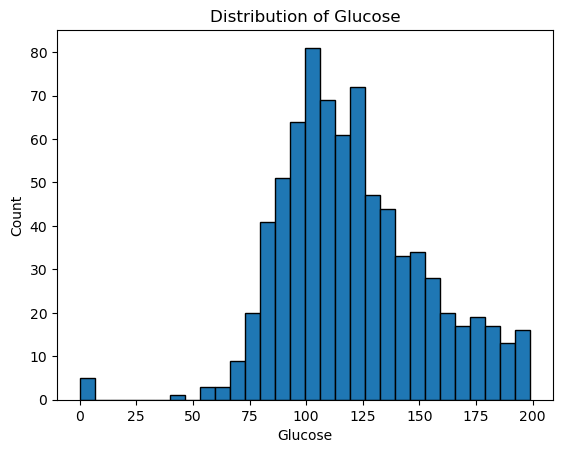

In [40]:
plt.figure()

# TO DO: histogram of Glucose (hint: plt.hist)
# Use 30 bins.
plt.hist(df['Glucose'], bins=30, edgecolor='black')

plt.title("Distribution of Glucose")
plt.xlabel("Glucose")
plt.ylabel("Count")
plt.show()


Interpretation: Describe shape, center, spread, and any unusual features/outliers.

Interpretation: The distribution of Glucose is roughly symmetric and bell-shaped, centered around 110-120. However, there is an unusual spike exactly at 0, which corresponds to the missing values we identified earlier.

### 3B. Histogram of BMI

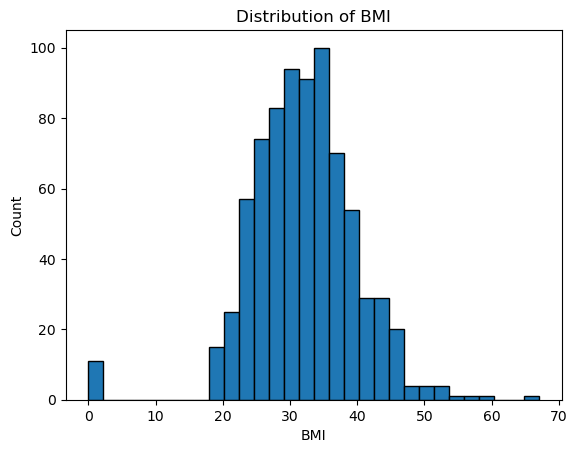

In [41]:
plt.figure()

# TO DO: histogram of BMI (hint: plt.hist)
# Use 30 bins.
plt.hist(df['BMI'], bins=30, edgecolor='black')

plt.title("Distribution of BMI")
plt.xlabel("BMI")
plt.ylabel("Count")
plt.show()


Interpretation: Describe shape, center, spread, and any unusual features/outliers.

Interpretation: The BMI distribution is slightly right-skewed, centered around 32, meaning most patients are overweight or obese. Similar to Glucose, there is a small, unusual spike at 0 representing missing measurements.

### 3C. Boxplot: Glucose by Outcome

C:\Users\CNC_413\AppData\Local\Temp\ipykernel_13484\2240947655.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([g0, g1], labels=["Outcome=0", "Outcome=1"])


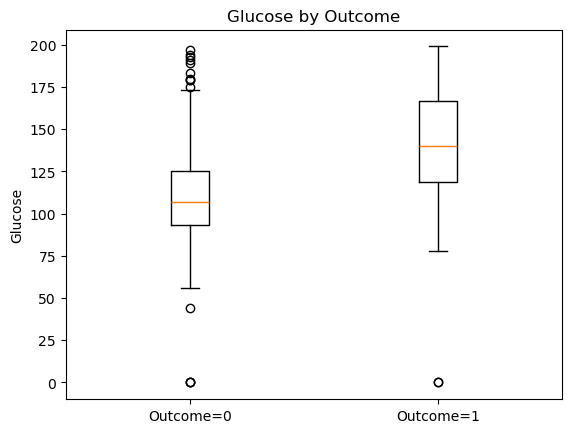

In [42]:
# TO DO: create two groups of Glucose values by Outcome
g0 = df[df['Outcome'] == 0]['Glucose']
g1 = df[df['Outcome'] == 1]['Glucose']

plt.figure()

# TO DO: boxplot comparing the two groups (hint: plt.boxplot)
# labels should be ["Outcome=0", "Outcome=1"]
plt.boxplot([g0, g1], labels=["Outcome=0", "Outcome=1"])

plt.title("Glucose by Outcome")
plt.ylabel("Glucose")
plt.show()


Interpretation: Compare medians and variability. Do the groups appear separated?

Interpretation: The median Glucose level for Outcome=1 (approx. 140) is noticeably higher than for Outcome=0 (approx. 107). The distributions are quite well-separated, suggesting Glucose is a strong predictor of the Outcome.

### 3D. Scatter: Age vs BMI (by Outcome)

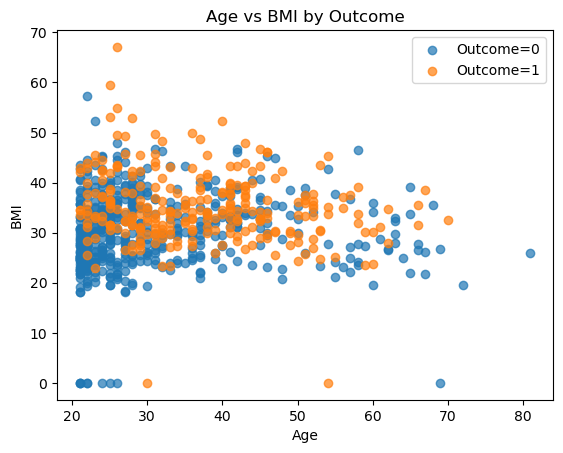

In [43]:
# TO DO: split dataset by Outcome
df0 = df[df['Outcome'] == 0]
df1 = df[df['Outcome'] == 1]

plt.figure()

# TO DO: scatter plots for the two groups (hint: plt.scatter)
# Use alpha=0.7 and include labels.
plt.scatter(df0['Age'], df0['BMI'], alpha=0.7, label="Outcome=0")
plt.scatter(df1['Age'], df1['BMI'], alpha=0.7, label="Outcome=1")

plt.title("Age vs BMI by Outcome")
plt.xlabel("Age")
plt.ylabel("BMI")
plt.legend()
plt.show()


Interpretation: Do you see clustering or separation between groups?

Interpretation: While there is no perfect separation, we can observe that Outcome=1 (red dots) tends to cluster more heavily in regions of higher BMI and older Age. Outcome=0 (blue dots) is highly concentrated in the younger age group (<30) with moderate BMI.

## 4. Group Comparison Summary (Descriptive)

TO DO:
1) Compute group means for Glucose, BMI, Age by Outcome  
2) Compute mean differences (Outcome=1 minus Outcome=0)  


In [44]:
# TO DO: group means table (hint: groupby + mean)
summary_means = df.groupby('Outcome')[['Glucose', 'BMI', 'Age']].mean()
summary_means


,Glucose,BMI,Age
Outcome,,,
0,109.980000,30.304200,31.190000
1,141.257463,35.142537,37.067164


In [45]:
# TO DO: compute mean differences (Outcome=1 minus Outcome=0)
# hint: summary_means.loc[1] - summary_means.loc[0]
mean_diff = summary_means.loc[1] - summary_means.loc[0]
mean_diff

Glucose    31.277463
BMI         4.838337
Age         5.877164
dtype: float64

Interpretation (5–8 lines):
- Which variables show the biggest differences between Outcome groups?
- Which 1–2 variables look most promising as “associated with Outcome” (based on descriptive evidence)?
- Be cautious: do not claim causality.


The Glucose variable shows the largest absolute difference between the Outcome groups (a difference of about 31.28). BMI and Age also show positive differences (4.84 and 5.88, respectively). Based on this descriptive evidence, Glucose looks like the most promising variable strongly associated with the diabetes outcome.

## 5. Sampling Simulation (Concept Preparation)

Goal: understand sampling variability of the sample mean.

TO DO:
1) Sample n = 30 observations (with replacement)  
2) Compute the sample mean of Glucose  
3) Repeat B = 1000 times  
4) Plot the distribution of sample means (matplotlib)  
5) Report the mean and standard deviation of the sampling distribution  


In [46]:
# TO DO: set simulation parameters
B = 1000
n = 30


In [47]:
means = []

for b in range(B):
    # TO DO: draw a bootstrap sample of size n (with replacement)
    sample = df.sample(n=n, replace=True)  # hint: df.sample
    
    # TO DO: compute mean of Glucose in this sample
    m = sample['Glucose'].mean()
    
    means.append(m)

means = np.array(means)

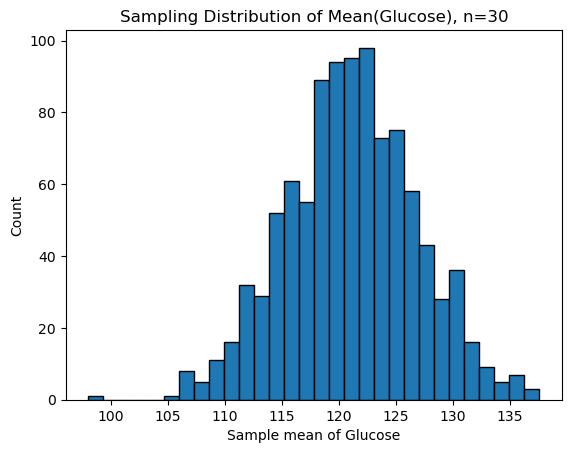

In [48]:
plt.figure()

# TO DO: histogram of simulated sample means (hint: plt.hist)
plt.hist(means, bins=30, edgecolor='black')

plt.title("Sampling Distribution of Mean(Glucose), n=30")
plt.xlabel("Sample mean of Glucose")
plt.ylabel("Count")
plt.show()

In [49]:
# TO DO: report center and spread of the sampling distribution
# hint: means.mean() and means.std(ddof=1)
center = means.mean()
spread = means.std(ddof=1)
center, spread

(121.0706, 5.75421545689882)

Interpretation (5–8 lines):
- What does the sampling distribution represent?
- Is it narrower than the raw Glucose distribution? Why?
- How does this connect to uncertainty of an estimate?


Interpretation:
The sampling distribution represents how the sample mean varies across 1000 repeated random samples. It is much narrower than the raw Glucose distribution because averaging n=30 observations smooths out individual extremes (following the Central Limit Theorem, Standard Error). This connects directly to statistical uncertainty: it shows the typical margin of error we can expect when using a sample mean to estimate the true population mean.

## Week B Consultation Checklist (Must Be Completed Before Consultation)

Before Week B, your group must have a **runnable draft** that includes:

1) Sections 1–5 completed (code runs without errors)  
2) All required plots (3A–3D) displayed correctly  
3) Group summary table (Section 4) + a short conclusion paragraph  
4) Sampling simulation completed (Section 5) + interpretation  
5) A proposed extension idea for Week C (next section)

No runnable draft → no Week B consultation mark.


## 6. Week C Extension

Choose **one** extension direction. The extension should add insight beyond the required analysis.

Examples (choose one):
- Correlation analysis (heatmap or top correlations with Outcome)
- Compare medians instead of means (robustness)
- Create age groups and compare outcomes across age bins
- Create BMI categories and compare outcome rates
- Another visualization (density, pairwise, etc.)

Write your plan first, then implement below.


### 6A. Extension Plan (5–8 lines)
TO DO: Write your plan here.
Extension Plan:
We will generate a Correlation Heatmap. This will allow us to observe the linear relationships between all continuous variables simultaneously, helping us confirm if variables like Glucose and BMI are indeed the most correlated with the Outcome, and to check for multicollinearity among predictors.

We will generate a Correlation Heatmap. This will allow us to observe the linear relationships between all continuous variables simultaneously, helping us confirm if variables like Glucose and BMI are indeed the most correlated with the Outcome, and to check for multicollinearity among predictors.

### 6B. Extension Implementation (code + outputs)

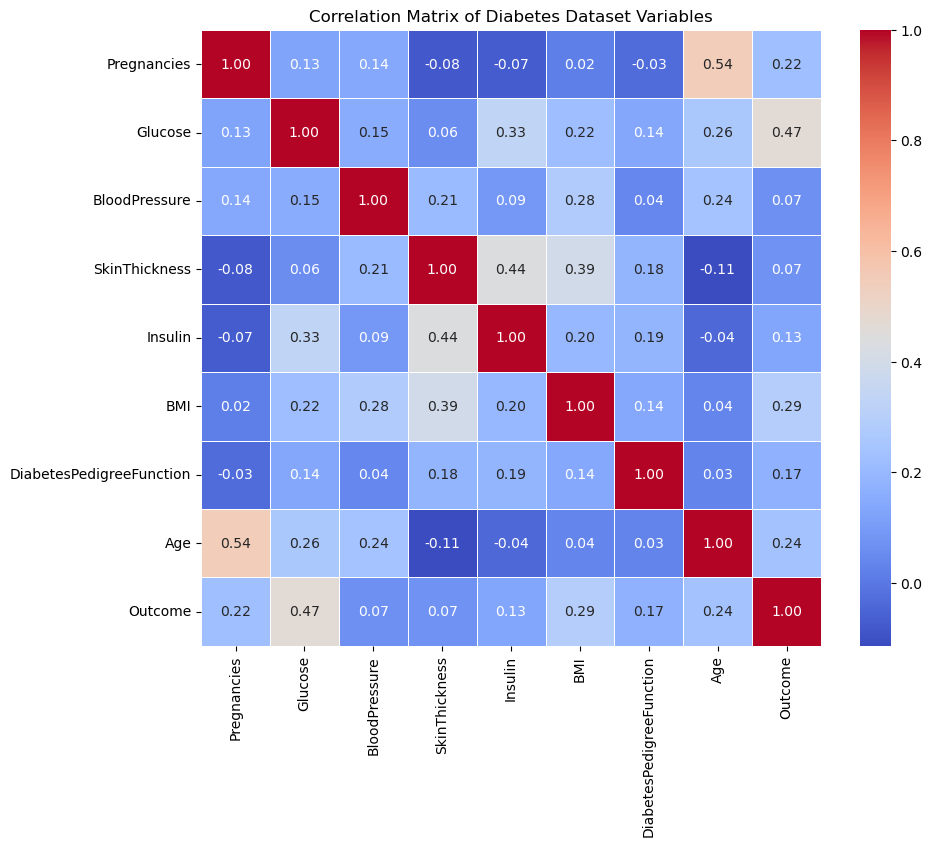

In [50]:
# TO DO: implement your extension here
import seaborn as sns

plt.figure(figsize=(10, 8))
# 計算相關係數矩陣
correlation_matrix = df.corr()

# 繪製熱力圖
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix of Diabetes Dataset Variables")
plt.show()


### 6C. Extension Interpretation (5–8 lines)
TO DO: Interpret what your extension shows and how it supports/changes your conclusions.

Extension Interpretation:
The heatmap confirms our descriptive findings: Glucose has the highest positive correlation with Outcome (0.47), followed by BMI (0.29) and Age (0.24). We also notice a strong correlation between Pregnancies and Age (0.54), which makes logical sense. This supports our conclusion that Glucose is the most critical feature for predicting diabetes in this dataset.

## 7. Week C Exhibition Reflection (After Rotations)

After you visit other groups during Week C, write at least **three** items:

1) One interesting analysis/visualization idea you saw  
2) One interpretation insight that was better than yours (what and why)  
3) One improvement you would apply to your own workflow next time  


Reflection notes:

1)We saw some groups have a great team works and coorperation, however some with acting like stranger to each other members.

2)Group 5's work was better than ours, beacuse their explanation is detailed and includes numerous charts, and additional programs are used to assist with data processing.

3)I would remove observations with missing or unrealistic values (such as zeros) and then use mean differences for comparison.
Although this reduces the sample size, it improves data quality and reduces noise in the analysis.
